In [2]:
from xopt.vocs import VOCS
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import UpperConfidenceBoundGenerator
from xopt import Xopt
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

# define variables and function objectives
vocs = VOCS(
    variables={"x": [0, 2 * math.pi]},
    objectives={"f": "MINIMIZE"},
)

In [3]:
# define a test function to optimize
def sin_function(input_dict):
    return {"f": np.sin(input_dict["x"])}

In [4]:
evaluator = Evaluator(function=sin_function)
generator = UpperConfidenceBoundGenerator(vocs=vocs)
generator.gp_constructor.use_low_noise_prior = True
X = Xopt(evaluator=evaluator, generator=generator)

In [5]:
# call X.random_evaluate() to generate + evaluate 3 initial points
X.random_evaluate(2)

# inspect the gathered data
X.data

,x,f,xopt_runtime,xopt_error
0,1.855234,0.959820,0.000027,False
1,1.662441,0.995804,0.000006,False


C:\Users\WThan\AppData\Local\Temp\ipykernel_9732\2254313937.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": np.sin(input_dict["x"])}
C:\Users\WThan\AppData\Local\Temp\ipykernel_9732\2254313937.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": np.sin(input_dict["x"])}
C:\Users\WThan\AppData\Local\Temp\ipykernel_9732\2254313937.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": np.sin(input_dict["x"])}
C:\Users\WThan\AppData\Local\Temp\ipykernel_9732\2254313937.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": np.sin(input_dict["x"])}
C:\Users\WThan\AppData\Local\Tem

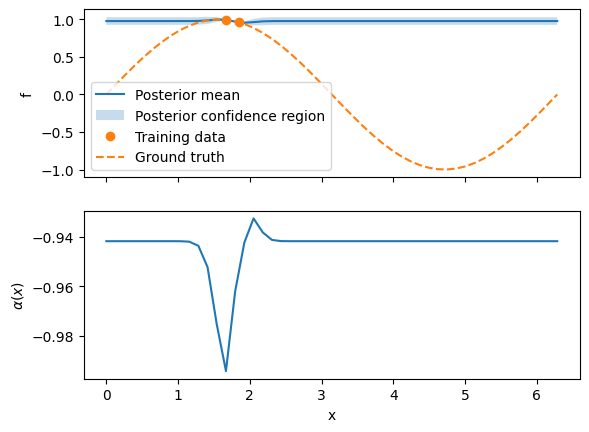

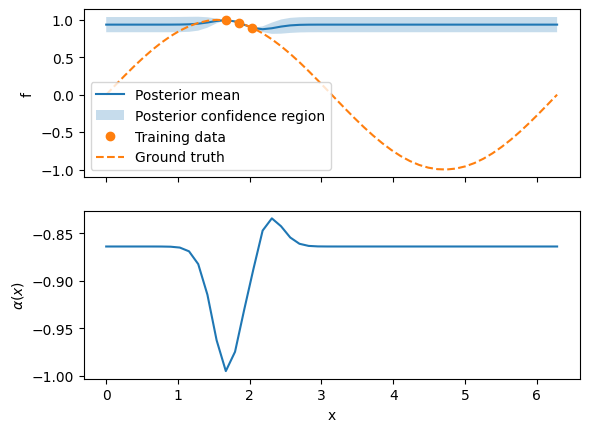

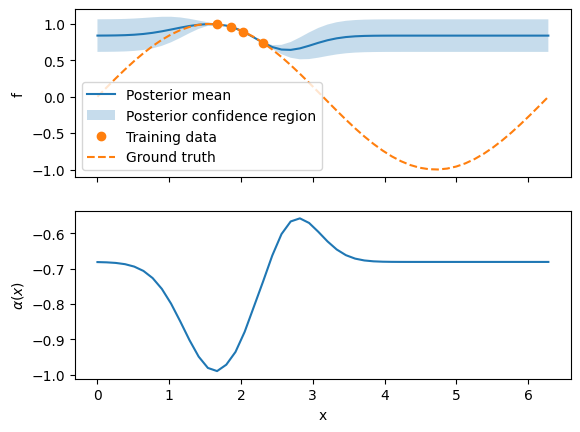

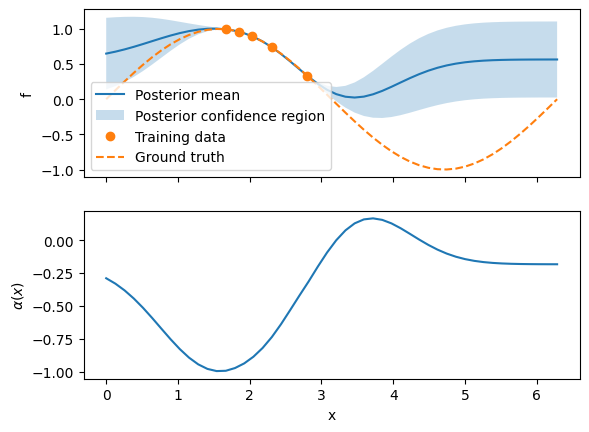

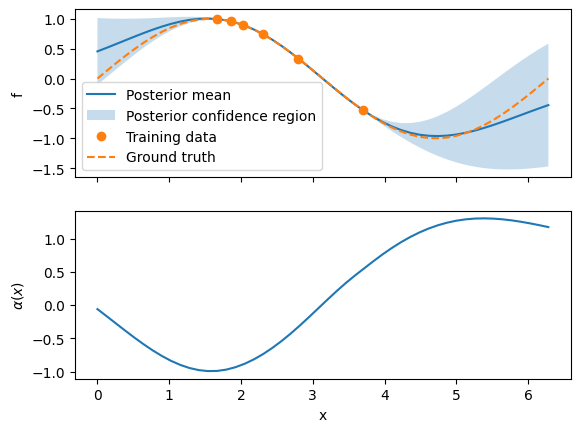

In [6]:
n_steps = 5

# test points for plotting
test_x = torch.linspace(*torch.tensor(X.vocs.bounds).flatten(), 50).double()

for i in range(n_steps):
    # get the Gaussian process model from the generator
    model = X.generator.train_model()

    # get acquisition function from generator
    acq = X.generator.get_acquisition(model)

    # calculate model posterior and acquisition function at each test point
    # NOTE: need to add a dimension to the input tensor for evaluating the
    # posterior and another for the acquisition function, see
    # https://botorch.org/docs/batching for details
    # NOTE: we use the `torch.no_grad()` environment to speed up computation by
    # skipping calculations for backpropagation
    with torch.no_grad():
        posterior = model.posterior(test_x.unsqueeze(1))
        acq_val = acq(test_x.reshape(-1, 1, 1))

    # get mean function and confidence regions
    mean = posterior.mean
    L, u = posterior.mvn.confidence_region()

    # plot model and acquisition function
    fig, ax = plt.subplots(2, 1, sharex="all")

    # plot model posterior
    ax[0].plot(test_x, mean, label="Posterior mean")
    ax[0].fill_between(test_x, L, u, alpha=0.25, label="Posterior confidence region")

    # add data to model plot
    ax[0].plot(X.data["x"], X.data["f"], "C1o", label="Training data")

    # plot true function
    true_f = sin_function({"x": test_x})["f"]
    ax[0].plot(test_x, true_f, "--", label="Ground truth")

    # add legend
    ax[0].legend()

    # plot acquisition function
    ax[1].plot(test_x, acq_val.flatten())

    ax[0].set_ylabel("f")
    ax[1].set_ylabel(r"$\alpha(x)$")
    ax[1].set_xlabel("x")

    # do the optimization step
    X.step()

In [7]:
# access the collected data
X.data

,x,f,xopt_runtime,xopt_error
0,1.855234,0.959820,0.000027,False
1,1.662441,0.995804,0.000006,False
2,2.032162,0.895445,0.000014,False
3,2.304564,0.742656,0.000014,False
4,2.801014,0.334033,0.000005,False
5,3.702873,-0.532270,0.000010,False
6,5.380026,-0.785287,0.000005,False


In [8]:
X.generator.get_optimum()

,x
0,4.728753


In [ ]:
X.generator.model_dump()

{'returns_id': False,
 'supports_single_objective': True,
 'supports_constraints': True,
 'vocs': {'variables': {'x': {'dtype': None,
    'default_value': None,
    'domain': [0.0, 6.283185307179586],
    'type': 'ContinuousVariable'}},
  'objectives': {'f': {'dtype': None, 'type': 'MinimizeObjective'}},
  'constraints': {},
  'constants': {},
  'observables': {}},
 'model': ModelListGP(
   (models): ModuleList(
     (0): SingleTaskGP(
       (likelihood): GaussianLikelihood(
         (noise_covar): HomoskedasticNoise(
           (noise_prior): GammaPrior()
           (raw_noise_constraint): GreaterThan(1.000E-04)
         )
       )
       (mean_module): ConstantMean()
       (covar_module): RBFKernel(
         (lengthscale_prior): LogNormalPrior()
         (raw_lengthscale_constraint): GreaterThan(2.500E-02)
       )
       (outcome_transform): Standardize()
       (input_transform): Normalize()
     )
   )
   (likelihood): LikelihoodList(
     (likelihoods): ModuleList(
       (0): 

: 